In [89]:
import pandas as pd
import numpy as np
import matplotlib as plt
import sklearn

**Crypto price prediction depends on two main factors: historical time series data and real-world market sentiment. Unlike stock price prediction, where price history often carries most of the signal, crypto is strongly influenced by traders' reactions to political, economic and financial events worldwide. Our dataset provides only the price side, namely open, high, low, close and daily variation, so we must separately obtain a sentiment score for each day in the historical window we are studying. Merging these daily scores with the OHLC data by date gives the model both price behavior and market mood as inputs.**

In [90]:
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 100
pd.options.display.max_columns = 25

In [91]:
# Load data from source

data = pd.read_csv(r"C:\Users\ACER\OneDrive\Desktop\ML Notes and colab Notebooks\Data Science Projects\Cryptoprice-prediction\notebook\data\eda.csv")

In [92]:
df = data.copy()

In [93]:
df

,close,crypto_name,date,volume,marketCap,variation,year,month,day
0,735.07,Bitcoin,2013-12-27,46862700.00,8955394563.50,8.96,2013,12,27
1,23.27,Litecoin,2013-12-27,31112200.00,566088038.79,13.50,2013,12,27
2,0.00,Dogecoin,2013-12-27,477422.00,8016603.65,26.41,2013,12,27
3,0.03,XRP,2013-12-27,148422.00,211674056.85,15.28,2013,12,27
4,0.03,XRP,2013-12-28,143404.00,213453408.57,5.55,2013,12,28
...,...,...,...,...,...,...,...,...,...
69247,0.02,VeChain,2022-10-23,40401338.08,1652957186.63,3.56,2022,10,23
69248,1.52,Flow,2022-10-23,28443510.43,1572824923.08,6.62,2022,10,23
69249,5.12,Filecoin,2022-10-23,106949683.62,1559551358.49,4.11,2022,10,23
69250,0.00,Terra Classic,2022-10-23,214326817.63,1576291167.45,7.54,2022,10,23


In [94]:
df['crypto_name'].value_counts()


crypto_name
Bitcoin                  3012
Litecoin                 3012
Dogecoin                 3012
XRP                      3011
Monero                   2866
Stellar                  2791
Ethereum                 2424
Ethereum Classic         2072
Tether                   1994
Basic Attention Token    1760
EOS                      1728
BNB                      1706
Bitcoin Cash             1699
Chainlink                1649
Decentraland             1641
TRON                     1641
Cardano                  1637
Maker                    1530
Theta Network            1524
Ravencoin                1469
Huobi Token              1431
Tezos                    1362
VeChain                  1332
Quant                    1274
USD Coin                 1257
Cronos                   1196
Cosmos                   1062
Polygon                  1054
UNUS SED LEO             1012
Chiliz                    983
FTX Token                 961
OKB                       956
Algorand                  95

# Feature Engeenering

In [95]:
df = df[df['crypto_name'] == "Bitcoin"].reset_index(drop=True)

In [96]:
df ['date'] = df['date'].sort_values()

In [97]:
df

,close,crypto_name,date,volume,marketCap,variation,year,month,day
0,735.07,Bitcoin,2013-12-27,46862700.00,8955394563.50,8.96,2013,12,27
1,727.83,Bitcoin,2013-12-28,32505800.00,8869918644.00,5.91,2013,12,28
2,745.05,Bitcoin,2013-12-29,19011300.00,9082103621.25,4.78,2013,12,29
3,756.13,Bitcoin,2013-12-30,20707700.00,9217167990.25,3.56,2013,12,30
4,754.01,Bitcoin,2013-12-31,20897300.00,9191325349.25,3.04,2013,12,31
...,...,...,...,...,...,...,...,...,...
3007,18802.10,Bitcoin,2022-09-25,23359966112.45,360259346858.07,2.34,2022,9,25
3008,19044.11,Bitcoin,2022-10-02,20765955327.49,365024821953.69,2.11,2022,10,2
3009,19446.43,Bitcoin,2022-10-09,16837262532.25,372876821416.38,1.00,2022,10,9
3010,19268.09,Bitcoin,2022-10-16,17988916650.36,369584293835.81,1.68,2022,10,16


<Axes: title={'center': 'Average Closing Price by Month and Year'}, xlabel='year,month'>

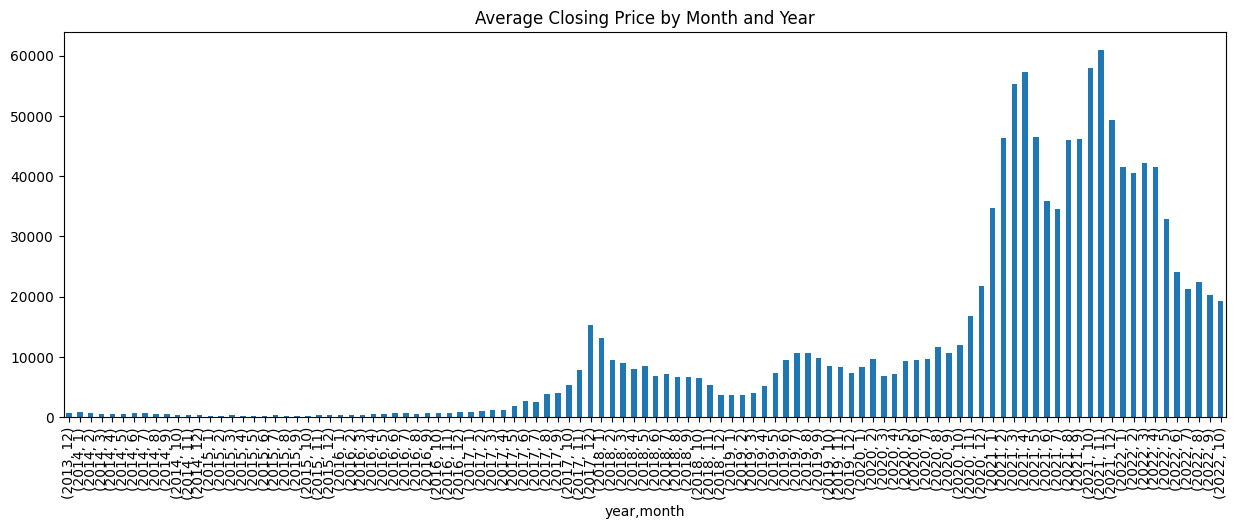

In [98]:
df.groupby(['year', 'month'])['close'].mean().plot(kind='bar', figsize=(15, 5), title='Average Closing Price by Month and Year')

In [99]:
df['returns'] = df["close"].pct_change()*100

In [100]:
df['lag_7'] = df["returns"].shift(7)
df['lag_14'] = df["returns"].shift(14)
df['lag_30'] = df["returns"].shift(30)

In [119]:
df.sample(2)

,close,crypto_name,date,volume,marketCap,variation,year,month,day,returns,lag_7,lag_14,lag_30
36,832.58,Bitcoin,2014-02-01,19668700.00,10275202812.00,3.19,2014,2,1,0.32,7.09,3.11,4.02
682,380.26,Bitcoin,2015-11-09,68224400.00,5635560842.80,6.17,2015,11,9,1.85,10.99,0.57,0.41


<Axes: title={'center': 'Returns and Lagged Returns'}, xlabel='date'>

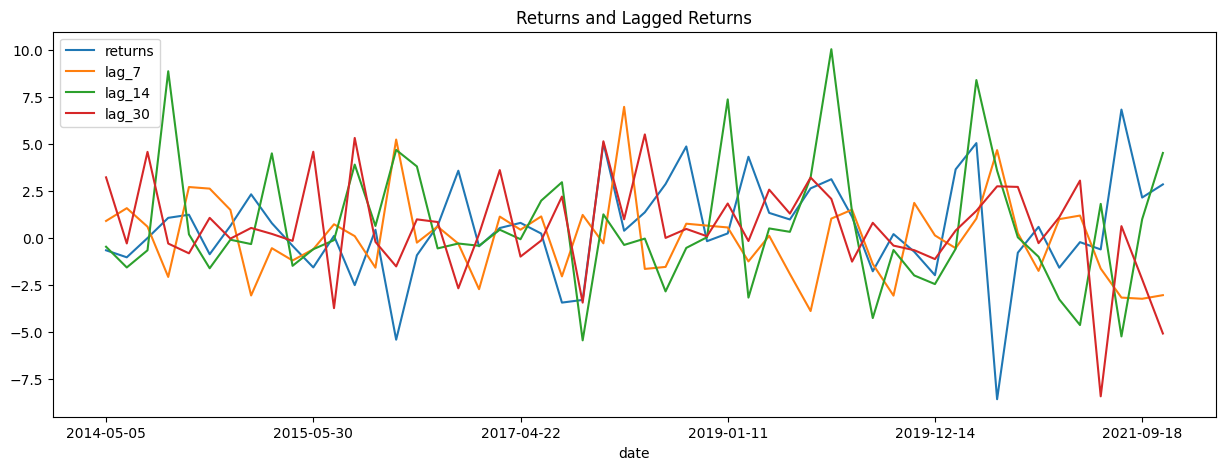

In [110]:
df.sample(52).sort_values(by='date').plot(x='date', y=['returns', 'lag_7', 'lag_14', 'lag_30'], figsize=(15, 5), title='Returns and Lagged Returns')

In [102]:
thresh_dat = '2021-01-01'

test_df = df[df['date'] >= thresh_dat]
train_df = df[df['date'] < thresh_dat]

In [103]:
test_df.shape

(459, 13)

In [104]:
train_df.shape

(2553, 13)

In [111]:
x_train = train_df[['volume', 'marketCap',  'year', 'month', 'day','returns','lag_30','lag_14','lag_7']]
y_train = train_df['close']



In [115]:
x_test = test_df[['volume', 'marketCap',  'year', 'month', 'day','returns','lag_30','lag_14','lag_7']]
y_test = test_df['close']

In [112]:
x_train.shape, y_train.shape

((2553, 9), (2553,))